L
et's create a superposition od states, that represent the ASCII representation of binary code for "K" and "P" letters.

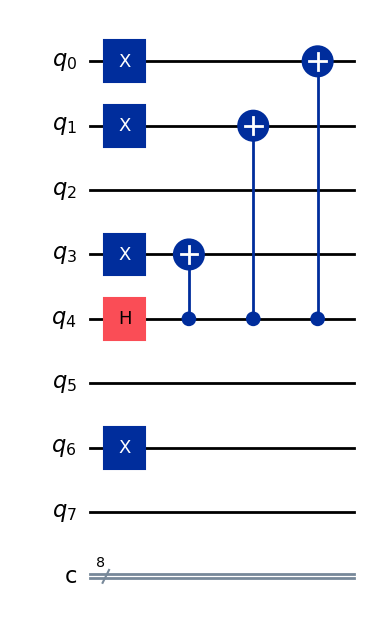

<IPython.core.display.Latex object>

{'01001011': 2054, '01010000': 2042}


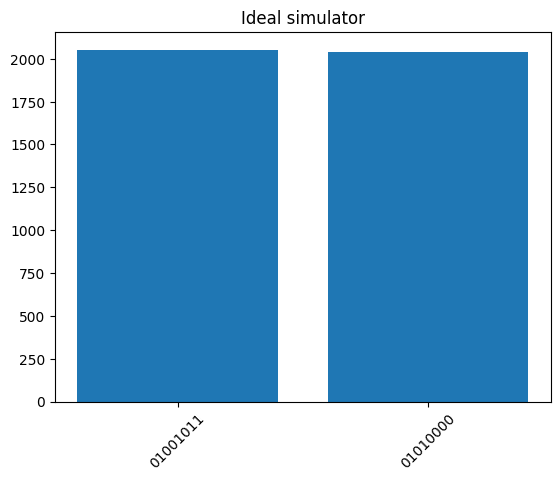

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# K = 0 1 0 0 1 0 1 1
# P = 0 1 0 1 0 0 0 0

qc = QuantumCircuit(8, 8)

qc.x(6)
qc.x(3)
qc.x(1)
qc.x(0)

qc.h(4)

qc.cx(4, 3)
qc.cx(4, 1)
qc.cx(4, 0)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
display(state.draw(output="latex"))

qc_meas = qc.copy()
qc_meas.measure(range(8), range(8))

backend = AerSimulator()
compiled = transpile(qc_meas, backend)
result = backend.run(compiled, shots=4096).result()
counts = result.get_counts()

print(counts)

plt.figure()
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.title("Ideal simulator")
plt.show()

Fake backend counts:
{'01011010': 1, '01001011': 1872, '11001011': 7, '01000011': 34, '01010000': 1940, '01101011': 10, '01001010': 21, '01010010': 19, '00001011': 20, '01010001': 18, '01011000': 37, '01010100': 10, '11001010': 1, '01000000': 19, '01100001': 1, '01110000': 8, '01011011': 13, '01001111': 14, '11010000': 9, '00010000': 12, '01000001': 15, '01000100': 1, '01001001': 10, '00001010': 1, '01011101': 1, '01010110': 1, '01000010': 1}


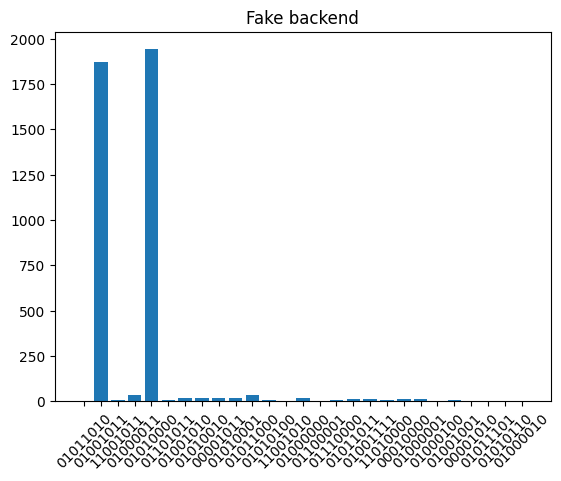

In [2]:
from qiskit_ibm_runtime.fake_provider import FakeAuckland

fake_backend = FakeAuckland()
noisy_backend = AerSimulator.from_backend(fake_backend)

compiled_noisy = transpile(qc_meas, noisy_backend)
result_noisy = noisy_backend.run(compiled_noisy, shots=4096).result()
counts_noisy = result_noisy.get_counts()

print("Fake backend counts:")
print(counts_noisy)

plt.figure()
plt.bar(counts_noisy.keys(), counts_noisy.values())
plt.xticks(rotation=45)
plt.title("Fake backend")
plt.show()